# NORMA Sensitivity Analysis

Explores how predictions change as we vary:
- **Age** — holding sex, history, and horizon fixed
- **Sex** — M vs F comparison
- **Prediction horizon** — days from last measurement to prediction date
- **History variance** — tight (low σ) vs spread (high σ) trajectories

Everything is static (no app required). Uses a fixed reference patient from the test set.

In [13]:
import sys, os
sys.path.insert(0, '../model')
sys.path.insert(0, '../process')
sys.path.insert(0, '../helpers')

import numpy as np
import pandas as pd
import torch
import pickle

from plots import *
from config import REFERENCE_INTERVALS
from utils import load_checkpoint, create_model
from data import TEST_VOCAB, CODE_TO_TEST_NAME

In [14]:
# ── Load model ──────────────────────────────────────────────────────────────
RUN_ID  = '167f05e8'
LOG_DIR = '../model/logs'
DEVICE  = torch.device('cpu')

ckpt, hparams = load_checkpoint(LOG_DIR, RUN_ID, best=True, device=DEVICE, quiet=True)
MODEL = create_model(hparams, ncodes=len(TEST_VOCAB), checkpoint=ckpt).to(DEVICE)
MODEL.eval()
NSTATES   = getattr(hparams, 'nstates', 3)
NORMALIZE = getattr(hparams, 'normalize', False)
print(f'Loaded {RUN_ID}  nstates={NSTATES}  normalize={NORMALIZE}')

Loaded 167f05e8  nstates=3  normalize=False


In [15]:
# ── Inference helper ─────────────────────────────────────────────────────────
STATE_LABELS = {0: 'Low', 1: 'Normal', 2: 'High'}

def value_to_state3(value, low, high):
    if value < low:  return 0
    if value > high: return 2
    return 1

def predict(test_name, sex01, age, t_arr, x_arr, t_next, state=1):
    """Run model inference. Returns (mu, sigma) in original units."""
    cid     = TEST_VOCAB[test_name]
    sex_str = 'F' if sex01 == 1 else 'M'
    low, high, unit = REFERENCE_INTERVALS[test_name][sex_str]

    t = np.array(t_arr, dtype=np.float32)
    x = np.array(x_arr, dtype=np.float32)

    if NORMALIZE:
        span = high - low
        x    = (x - low) / span

    s_arr = np.array([value_to_state3(v, low, high) for v in
                      (x * (high - low) + low if NORMALIZE else x)], dtype=np.int64)

    x_h = torch.tensor(x).view(1, -1, 1).float()
    s_h = torch.tensor(s_arr).view(1, -1).long()
    t_h = torch.tensor(t).view(1, -1, 1).float()
    sex_t    = torch.tensor([sex01]).long()
    age_t    = torch.tensor([[age]]).float()
    cid_t    = torch.tensor([cid]).long()
    s_next_t = torch.tensor([[state]]).long()
    t_next_t = torch.tensor([[t_next]]).float()

    with torch.no_grad():
        mu_t, lv_t = MODEL(x_h, s_h, t_h, sex_t, age_t, cid_t, s_next_t, t_next_t, pad_mask=None)

    mu    = float(mu_t.squeeze())
    sigma = float(torch.exp(0.5 * lv_t).squeeze())

    if NORMALIZE:
        span  = high - low
        mu    = mu    * span + low
        sigma = sigma * span

    return mu, sigma

In [16]:
# ── Reference patient ────────────────────────────────────────────────────────
# Change TEST_NAME to explore a different lab test
TEST_NAME = 'HGB'

seqs_path = '../data/processed/combined_sequences_v2.pkl'
with open(seqs_path, 'rb') as f:
    all_seqs = pickle.load(f)

candidates = [s for s in all_seqs if s['test_name'] == TEST_NAME and len(s['x']) >= 6]
import random; random.seed(42)
ref_seq = random.choice(candidates)

REF_SEX  = int(ref_seq['sex'])
REF_AGE  = float(ref_seq['age'])
REF_X    = ref_seq['x'].tolist()
REF_T    = ref_seq['t'].tolist()       # days from first measurement
BASE_T   = REF_T[-1] + 30             # predict 30 days after last observation
HIST_X   = REF_X[:-1]
HIST_T   = REF_T[:-1]

sex_str = 'F' if REF_SEX == 1 else 'M'
ref_low, ref_high, unit = REFERENCE_INTERVALS[TEST_NAME][sex_str]
print(f'Reference patient: {TEST_NAME}, {sex_str}, age {REF_AGE:.0f}')
print(f'History: {len(HIST_X)} points over {HIST_T[-1]:.0f} days')
print(f'Population ref: {ref_low}–{ref_high} {unit}')

Reference patient: HGB, M, age 27
History: 191 points over 819 days
Population ref: 14–18 g/dL


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SENSITIVITY ANALYSIS — Synthetic baseline, one-at-a-time sweeps
# ─────────────────────────────────────────────────────────────────────────────
# Baseline: midpoint of reference range, 10 measurements every 90 days,
#           age=50, sex=M, horizon=30 days, zero variance (flat line).
# Tracks both CI width AND predicted mu (as % deviation from midpoint).
# history_std: sampled. All others: deterministic.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

BASELINE_N_HIST  = 10
BASELINE_SPACING = 90
BASELINE_AGE     = 50
BASELINE_SEX     = 0
BASELINE_HORIZON = 30
N_SAMPLES        = 30

EXCLUDE_LABS = {'LDH', 'GGT', 'CRP'}

SWEEPS = {
    'age':            np.arange(20, 81, 5),
    'sex':            [0, 1],
    'history_length': [2, 3, 4, 5, 6, 8, 10, 15, 20, 30, 50, 75, 100, 150, 200, 250, 300],
    'horizon':        [7, 14, 30, 60, 90, 180, 365, 730, 1095, 1825, 2555, 3650],
    'history_std':    np.linspace(0.0, 3.0, 13),
}

def make_flat_history(midpoint, n_hist, spacing):
    t = np.arange(n_hist, dtype=float) * spacing
    x = np.full(n_hist, midpoint, dtype=float)
    return t, x

def make_noisy_history(midpoint, n_hist, spacing, std_abs, rng):
    t = np.arange(n_hist, dtype=float) * spacing
    x = rng.normal(loc=midpoint, scale=std_abs, size=n_hist)
    return t, x

def predict_mu_and_ci(test_name, sex, age, t_hist, x_hist, horizon):
    t_next = t_hist[-1] + horizon
    mu, sigma = predict(test_name, sex, age, t_hist.tolist(), x_hist.tolist(), t_next, state=1)
    return mu, 1.96 * 2 * sigma

# ── Run all sweeps ──────────────────────────────────────────────────────────
all_test_names = sorted([k for k in REFERENCE_INTERVALS.keys()
                         if k in {s['test_name'] for s in all_seqs} and k not in EXCLUDE_LABS])

records = []
for test_name in tqdm(all_test_names, desc='Labs'):
    sex_str = 'F' if BASELINE_SEX == 1 else 'M'
    low, high, _ = REFERENCE_INTERVALS[test_name][sex_str]
    midpoint = (low + high) / 2.0
    ref_span = high - low

    t0, x0 = make_flat_history(midpoint, BASELINE_N_HIST, BASELINE_SPACING)
    try:
        baseline_mu, baseline_ci = predict_mu_and_ci(test_name, BASELINE_SEX, BASELINE_AGE, t0, x0, BASELINE_HORIZON)
    except Exception:
        continue

    for feature, vals in SWEEPS.items():
        if feature == 'history_std':
            for v in vals:
                std_abs = v * ref_span / 10.0
                mus, widths = [], []
                for i in range(N_SAMPLES):
                    rng = np.random.default_rng(i)
                    if std_abs > 0:
                        t_h, x_h = make_noisy_history(midpoint, BASELINE_N_HIST, BASELINE_SPACING, std_abs, rng)
                    else:
                        t_h, x_h = make_flat_history(midpoint, BASELINE_N_HIST, BASELINE_SPACING)
                    try:
                        m, w = predict_mu_and_ci(test_name, BASELINE_SEX, BASELINE_AGE, t_h, x_h, BASELINE_HORIZON)
                        mus.append(m); widths.append(w)
                    except Exception:
                        pass
                if len(widths) < 2:
                    continue
                ci_arr, mu_arr = np.array(widths), np.array(mus)
                records.append({
                    'test_name': test_name, 'feature': feature, 'value': v,
                    'ci_mean': ci_arr.mean(), 'ci_std': ci_arr.std(),
                    'ci_lo': np.percentile(ci_arr, 2.5), 'ci_hi': np.percentile(ci_arr, 97.5),
                    'baseline_ci': baseline_ci,
                    'pct_change': (ci_arr.mean() - baseline_ci) / baseline_ci * 100,
                    'pct_lo': (np.percentile(ci_arr, 2.5) - baseline_ci) / baseline_ci * 100,
                    'pct_hi': (np.percentile(ci_arr, 97.5) - baseline_ci) / baseline_ci * 100,
                    'mu_mean': mu_arr.mean(), 'mu_std': mu_arr.std(),
                    'mu_lo': np.percentile(mu_arr, 2.5), 'mu_hi': np.percentile(mu_arr, 97.5),
                    'midpoint': midpoint,
                    'mu_pct_dev': (mu_arr.mean() - midpoint) / midpoint * 100,
                })
        else:
            for v in vals:
                age, sex, n_hist, horizon = BASELINE_AGE, BASELINE_SEX, BASELINE_N_HIST, BASELINE_HORIZON
                if   feature == 'age':            age = v
                elif feature == 'sex':            sex = int(v)
                elif feature == 'history_length': n_hist = int(v)
                elif feature == 'horizon':        horizon = v

                t_h, x_h = make_flat_history(midpoint, n_hist, BASELINE_SPACING)
                try:
                    mu_val, ci_w = predict_mu_and_ci(test_name, sex, age, t_h, x_h, horizon)
                except Exception:
                    continue
                records.append({
                    'test_name': test_name, 'feature': feature, 'value': v,
                    'ci_mean': ci_w, 'ci_std': 0.0, 'ci_lo': ci_w, 'ci_hi': ci_w,
                    'baseline_ci': baseline_ci,
                    'pct_change': (ci_w - baseline_ci) / baseline_ci * 100,
                    'pct_lo': (ci_w - baseline_ci) / baseline_ci * 100,
                    'pct_hi': (ci_w - baseline_ci) / baseline_ci * 100,
                    'mu_mean': mu_val, 'mu_std': 0.0, 'mu_lo': mu_val, 'mu_hi': mu_val,
                    'midpoint': midpoint,
                    'mu_pct_dev': (mu_val - midpoint) / midpoint * 100,
                })

results_df = pd.DataFrame(records)
print(f'{len(results_df)} rows | {results_df.test_name.nunique()} labs | '
      f'{results_df.feature.nunique()} features | {N_SAMPLES} samples for history_std')
results_df.head(10)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1: Per-feature sweep curves — 2 rows:
#   Top:    CI width % change from baseline
#   Bottom: Predicted mu % deviation from midpoint
# ─────────────────────────────────────────────────────────────────────────────
import seaborn as sns
sns.set_context('paper', font_scale=1.3)
sns.set_style('white')

features = list(SWEEPS.keys())
n_feat = len(features)
labs = all_test_names

palette = sns.color_palette('tab20', n_colors=len(labs))
lab_cmap = {lab: palette[i] for i, lab in enumerate(labs)}

fig, axes = plt.subplots(2, n_feat, figsize=(4.5 * n_feat, 7), sharey='row')

# Row 0: CI width % change
for ax, feature in zip(axes[0], features):
    sub = results_df[results_df['feature'] == feature]
    for lab in labs:
        d = sub[sub['test_name'] == lab].sort_values('value')
        if d.empty:
            continue
        ax.plot(d['value'], d['pct_change'], 'o-', color=lab_cmap[lab],
                lw=1.5, ms=3, alpha=0.7)
        if feature == 'history_std':
            ax.fill_between(d['value'], d['pct_lo'], d['pct_hi'],
                            color=lab_cmap[lab], alpha=0.1)
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold')
    if ax == axes[0][0]:
        ax.set_ylabel('CI width change (%)')

# Row 1: mu % deviation from midpoint
for ax, feature in zip(axes[1], features):
    sub = results_df[results_df['feature'] == feature]
    for lab in labs:
        d = sub[sub['test_name'] == lab].sort_values('value')
        if d.empty:
            continue
        ax.plot(d['value'], d['mu_pct_dev'], 'o-', color=lab_cmap[lab],
                lw=1.5, ms=3, alpha=0.7)
        if feature == 'history_std':
            mu_lo_pct = (d['mu_lo'] - d['midpoint']) / d['midpoint'] * 100
            mu_hi_pct = (d['mu_hi'] - d['midpoint']) / d['midpoint'] * 100
            ax.fill_between(d['value'], mu_lo_pct, mu_hi_pct,
                            color=lab_cmap[lab], alpha=0.1)
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.set_xlabel(feature.replace('_', ' ').title())
    if ax == axes[1][0]:
        ax.set_ylabel('Predicted mu deviation\nfrom midpoint (%)')

handles = [plt.Line2D([0], [0], color=lab_cmap[l], lw=2, label=l) for l in labs]
fig.legend(handles=handles, title='Lab', bbox_to_anchor=(1.01, 0.5),
           loc='center left', frameon=False, fontsize=9, title_fontsize=10)
sns.despine(fig)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.savefig('../figures/sensitivity_sweep_curves.png', dpi=200, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2: Effect-size summary — range bars for both CI width and mu deviation
# ─────────────────────────────────────────────────────────────────────────────
effect_df = (results_df
    .groupby(['test_name', 'feature'])
    .agg(ci_pct_min=('pct_change', 'min'),
         ci_pct_max=('pct_change', 'max'),
         ci_pct_range=('pct_change', lambda x: x.max() - x.min()),
         mu_pct_min=('mu_pct_dev', 'min'),
         mu_pct_max=('mu_pct_dev', 'max'),
         mu_pct_range=('mu_pct_dev', lambda x: x.max() - x.min()))
    .reset_index())

fig, axes = plt.subplots(2, n_feat, figsize=(4.5 * n_feat, 9), sharey='row')

for row, (metric, label) in enumerate([('ci_pct', 'CI width change (%)'), ('mu_pct', 'Mu deviation from midpoint (%)')]):
    for ax, feature in zip(axes[row], features):
        sub = effect_df[effect_df['feature'] == feature].sort_values(f'{metric}_range', ascending=True)
        for i, (_, r) in enumerate(sub.iterrows()):
            ax.barh(i, r[f'{metric}_max'] - r[f'{metric}_min'], left=r[f'{metric}_min'],
                    color=lab_cmap.get(r['test_name'], 'gray'), edgecolor='black',
                    linewidth=0.5, height=0.7, alpha=0.8)
        ax.set_yticks(range(len(sub)))
        ax.set_yticklabels(sub['test_name'])
        ax.axvline(0, color='gray', ls='--', lw=0.8)
        ax.set_xlabel(label)
        ax.set_title(feature.replace('_', ' ').title(), fontweight='bold')

fig.suptitle('Sensitivity: CI Width and Predicted Mean (% change from baseline)',
             fontsize=13, fontweight='bold', y=1.02)
sns.despine(fig)
plt.tight_layout()
plt.savefig('../figures/sensitivity_effect_sizes.png', dpi=200, bbox_inches='tight')
plt.show()

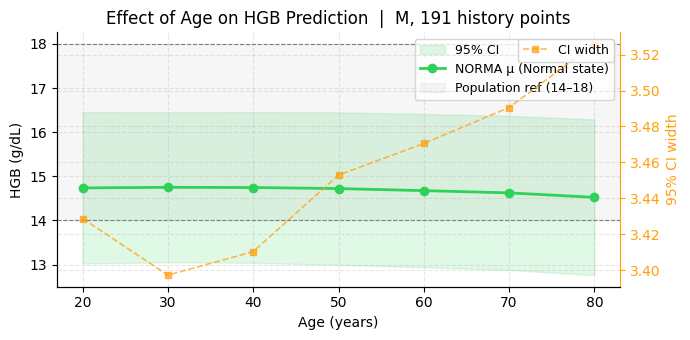

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. AGE SWEEP
# ─────────────────────────────────────────────────────────────────────────────
ages = [20, 30, 40, 50, 60, 70, 80]
age_results = {}
for age in ages:
    mu, sigma = predict(TEST_NAME, REF_SEX, age, HIST_T, HIST_X, BASE_T, state=1)
    age_results[age] = {'mu': mu, 'sigma': sigma,
                        'ci_lo': mu - 1.96*sigma, 'ci_hi': mu + 1.96*sigma}

fig, ax = plt.subplots(figsize=(7, 3.5))
xs   = list(age_results.keys())
mus  = [age_results[a]['mu']    for a in xs]
lo   = [age_results[a]['ci_lo'] for a in xs]
hi   = [age_results[a]['ci_hi'] for a in xs]
widths = [age_results[a]['ci_hi'] - age_results[a]['ci_lo'] for a in xs]

ax.fill_between(xs, lo, hi, alpha=0.15, color='#30d158', label='95% CI')
ax.plot(xs, mus, 'o-', color='#30d158', lw=2, ms=6, label='NORMA μ (Normal state)')
ax.axhspan(ref_low, ref_high, alpha=0.07, color='gray', label=f'Population ref ({ref_low}–{ref_high})')
ax.axhline(ref_low,  color='gray', lw=0.8, ls='--')
ax.axhline(ref_high, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Age (years)'); ax.set_ylabel(f'{TEST_NAME} ({unit})')
ax.set_title(f'Effect of Age on {TEST_NAME} Prediction  |  {sex_str}, {len(HIST_X)} history points')
ax.legend(fontsize=9)

ax2 = ax.twinx()
ax2.plot(xs, widths, 's--', color='#ff9f0a', lw=1.2, ms=5, alpha=0.7, label='CI width')
ax2.set_ylabel('95% CI width', color='#ff9f0a')
ax2.tick_params(axis='y', colors='#ff9f0a')
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color('#ff9f0a')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/sensitivity_age.png', dpi=150, bbox_inches='tight')
plt.show()

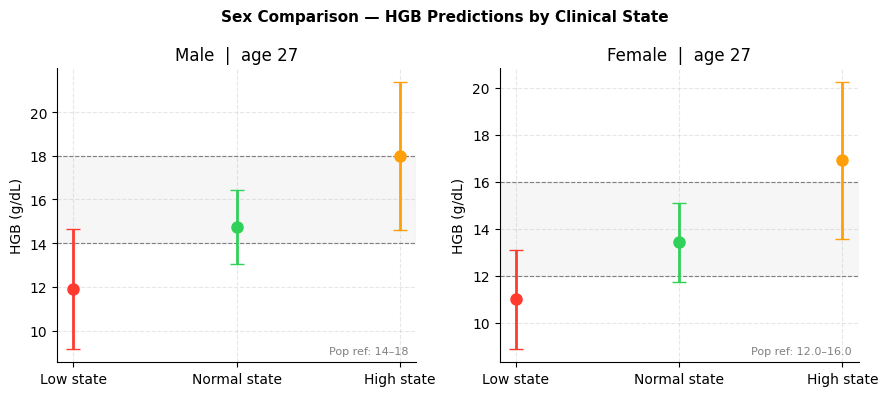

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. SEX COMPARISON
# ─────────────────────────────────────────────────────────────────────────────
sex_map   = {0: 'Male', 1: 'Female'}
sex_colors = {0: '#0071e3', 1: '#bf5af2'}
sex_results = {}

for sex01 in [0, 1]:
    sex_str_i = 'F' if sex01 == 1 else 'M'
    lo_r, hi_r, _ = REFERENCE_INTERVALS[TEST_NAME][sex_str_i]
    state_res = {}
    for state in [0, 1, 2]:
        mu, sigma = predict(TEST_NAME, sex01, REF_AGE, HIST_T, HIST_X, BASE_T, state=state)
        state_res[state] = {'mu': mu, 'sigma': sigma,
                            'ci_lo': mu - 1.96*sigma, 'ci_hi': mu + 1.96*sigma,
                            'ref_lo': lo_r, 'ref_hi': hi_r}
    sex_results[sex01] = state_res

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=False)
state_labels_plot = {0: 'Low', 1: 'Normal', 2: 'High'}
state_colors_plot = {0: '#ff3b30', 1: '#30d158', 2: '#ff9f0a'}

for col, sex01 in enumerate([0, 1]):
    ax = axes[col]
    sr = sex_results[sex01]
    ref_lo_s = sr[1]['ref_lo']; ref_hi_s = sr[1]['ref_hi']
    ax.axhspan(ref_lo_s, ref_hi_s, alpha=0.07, color='gray')
    ax.axhline(ref_lo_s, color='gray', lw=0.8, ls='--')
    ax.axhline(ref_hi_s, color='gray', lw=0.8, ls='--')

    xs_s = [0, 1, 2]
    mus  = [sr[s]['mu']    for s in xs_s]
    lo   = [sr[s]['ci_lo'] for s in xs_s]
    hi   = [sr[s]['ci_hi'] for s in xs_s]

    for s in xs_s:
        ax.errorbar(s, sr[s]['mu'],
                    yerr=[[sr[s]['mu'] - sr[s]['ci_lo']], [sr[s]['ci_hi'] - sr[s]['mu']]],
                    fmt='o', color=state_colors_plot[s], ms=8, capsize=5, lw=2)

    ax.set_xticks([0,1,2])
    ax.set_xticklabels(['Low state', 'Normal state', 'High state'])
    ax.set_ylabel(f'{TEST_NAME} ({unit})')
    ax.set_title(f'{sex_map[sex01]}  |  age {REF_AGE:.0f}')
    ax.text(0.98, 0.02, f'Pop ref: {ref_lo_s}–{ref_hi_s}', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='gray')

fig.suptitle(f'Sex Comparison — {TEST_NAME} Predictions by Clinical State', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/sensitivity_sex.png', dpi=150, bbox_inches='tight')
plt.show()

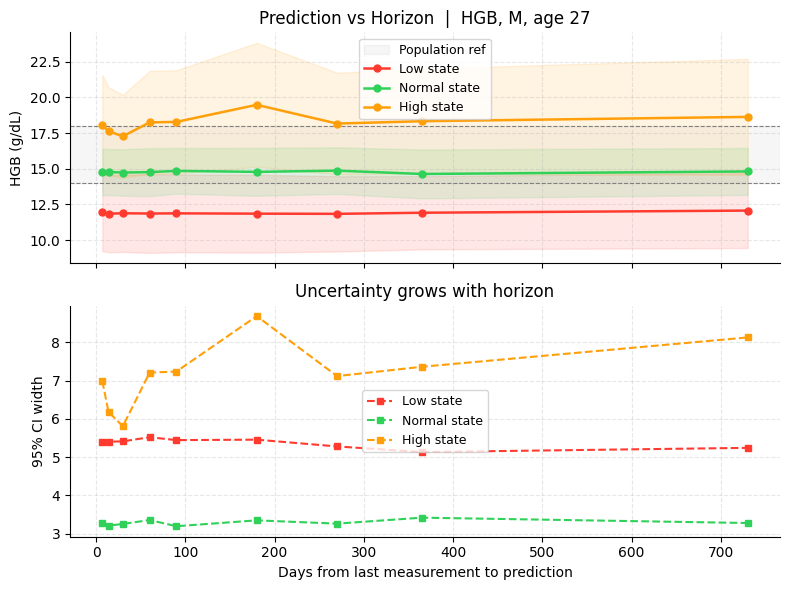

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. PREDICTION HORIZON SWEEP
# ─────────────────────────────────────────────────────────────────────────────
horizons = [7, 14, 30, 60, 90, 180, 270, 365, 730]  # days from last measurement
last_t   = HIST_T[-1]

horizon_results = {}
for h in horizons:
    t_next = last_t + h
    state_res = {}
    for state in [0, 1, 2]:
        mu, sigma = predict(TEST_NAME, REF_SEX, REF_AGE, HIST_T, HIST_X, t_next, state=state)
        state_res[state] = {'mu': mu, 'sigma': sigma,
                            'ci_lo': mu - 1.96*sigma, 'ci_hi': mu + 1.96*sigma,
                            'width': 1.96*2*sigma}
    horizon_results[h] = state_res

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
state_colors_plot = {0: '#ff3b30', 1: '#30d158', 2: '#ff9f0a'}
state_labels_plot = {0: 'Low', 1: 'Normal', 2: 'High'}

ax1.axhspan(ref_low, ref_high, alpha=0.07, color='gray', label='Population ref')
ax1.axhline(ref_low,  color='gray', lw=0.8, ls='--')
ax1.axhline(ref_high, color='gray', lw=0.8, ls='--')

for state in [0, 1, 2]:
    mus   = [horizon_results[h][state]['mu']    for h in horizons]
    lo    = [horizon_results[h][state]['ci_lo'] for h in horizons]
    hi    = [horizon_results[h][state]['ci_hi'] for h in horizons]
    color = state_colors_plot[state]
    ax1.fill_between(horizons, lo, hi, alpha=0.12, color=color)
    ax1.plot(horizons, mus, 'o-', color=color, lw=1.8, ms=5, label=f'{state_labels_plot[state]} state')

ax1.set_ylabel(f'{TEST_NAME} ({unit})')
ax1.set_title(f'Prediction vs Horizon  |  {TEST_NAME}, {"F" if REF_SEX else "M"}, age {REF_AGE:.0f}')
ax1.legend(fontsize=9)

# CI width (uncertainty) vs horizon
for state in [0, 1, 2]:
    widths = [horizon_results[h][state]['width'] for h in horizons]
    ax2.plot(horizons, widths, 's--', color=state_colors_plot[state], lw=1.5, ms=5,
             label=f'{state_labels_plot[state]} state')

ax2.set_xlabel('Days from last measurement to prediction')
ax2.set_ylabel('95% CI width')
ax2.set_title('Uncertainty grows with horizon')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../figures/sensitivity_horizon.png', dpi=150, bbox_inches='tight')
plt.show()

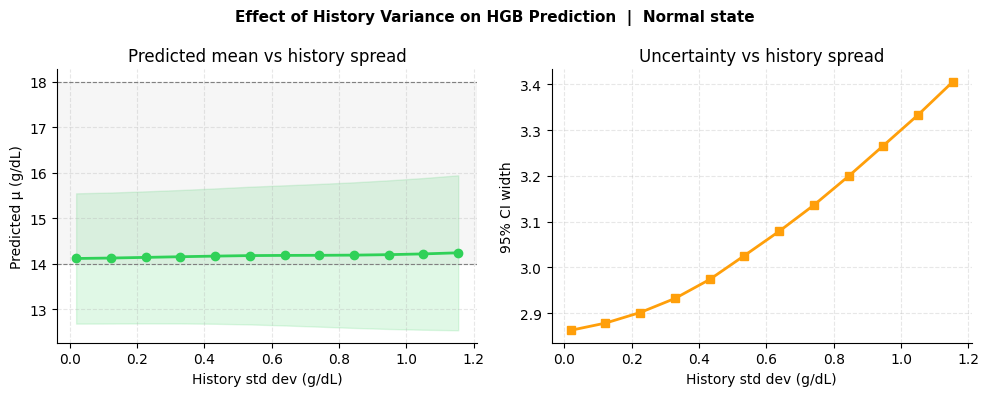

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. HISTORY VARIANCE SWEEP
# ─────────────────────────────────────────────────────────────────────────────
# Fix the history timing (same days) but vary how spread out the values are.
# We construct synthetic histories centred at the patient's mean with
# increasing standard deviation.

hist_mean = float(np.mean(HIST_X))
hist_t    = HIST_T  # same timestamps for all
n_hist    = len(HIST_X)

# Use a fixed random pattern scaled to different σ values
rng = np.random.default_rng(0)
unit_noise = rng.standard_normal(n_hist)
unit_noise -= unit_noise.mean()

sigmas_to_sweep = np.linspace(0.05, 3.0, 12)  # multiples of (ref_high - ref_low) / 10
scale = (ref_high - ref_low) / 10

var_results = {}
for s in sigmas_to_sweep:
    hist_x_synth = hist_mean + unit_noise * s * scale
    mu, sigma = predict(TEST_NAME, REF_SEX, REF_AGE, hist_t, hist_x_synth.tolist(), BASE_T, state=1)
    var_results[round(s, 3)] = {'mu': mu, 'sigma': sigma,
                                'ci_lo': mu - 1.96*sigma, 'ci_hi': mu + 1.96*sigma,
                                'hist_std': float(hist_x_synth.std())}

hist_stds = [var_results[s]['hist_std'] for s in var_results]
mus       = [var_results[s]['mu']       for s in var_results]
ci_widths = [var_results[s]['ci_hi'] - var_results[s]['ci_lo'] for s in var_results]
ci_lo     = [var_results[s]['ci_lo']   for s in var_results]
ci_hi     = [var_results[s]['ci_hi']   for s in var_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.fill_between(hist_stds, ci_lo, ci_hi, alpha=0.15, color='#30d158')
ax1.plot(hist_stds, mus, 'o-', color='#30d158', lw=2, ms=6)
ax1.axhspan(ref_low, ref_high, alpha=0.07, color='gray')
ax1.axhline(ref_low,  color='gray', lw=0.8, ls='--')
ax1.axhline(ref_high, color='gray', lw=0.8, ls='--')
ax1.set_xlabel(f'History std dev ({unit})')
ax1.set_ylabel(f'Predicted μ ({unit})')
ax1.set_title('Predicted mean vs history spread')

ax2.plot(hist_stds, ci_widths, 's-', color='#ff9f0a', lw=2, ms=6)
ax2.set_xlabel(f'History std dev ({unit})')
ax2.set_ylabel('95% CI width')
ax2.set_title('Uncertainty vs history spread')

fig.suptitle(f'Effect of History Variance on {TEST_NAME} Prediction  |  Normal state', 
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/sensitivity_variance.png', dpi=150, bbox_inches='tight')
plt.show()

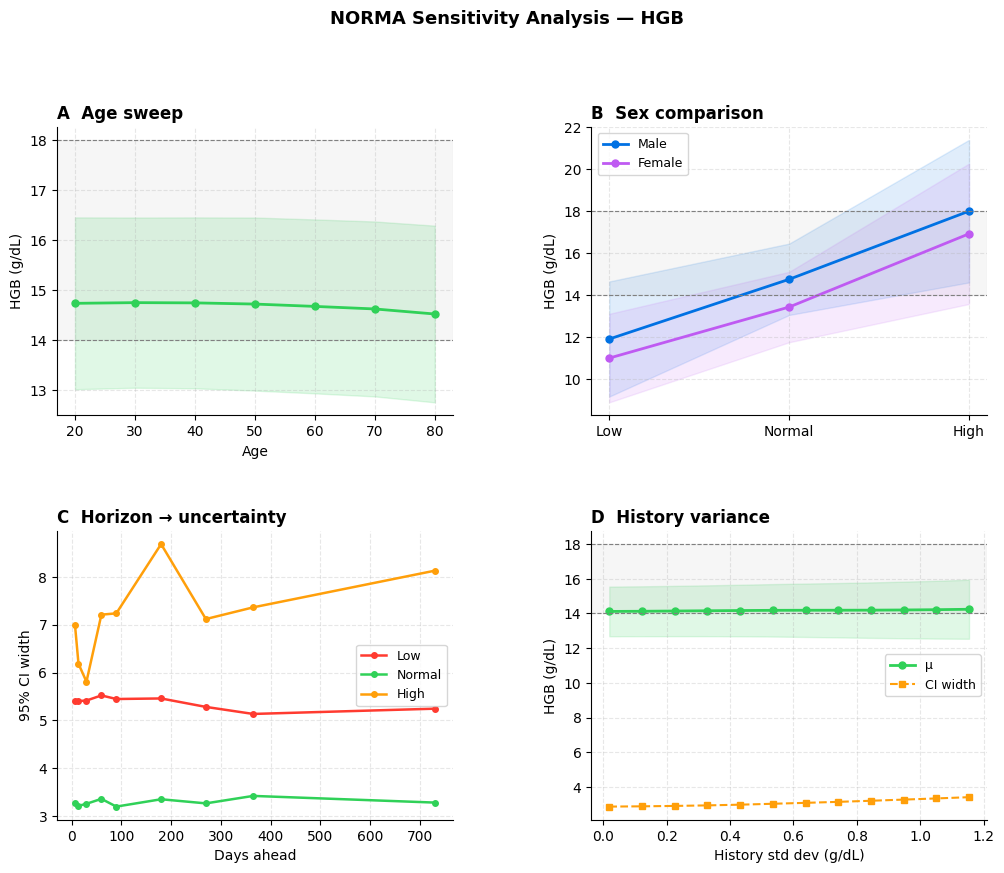

Saved to ../figures/sensitivity_summary.png


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. COMBINED SUMMARY FIGURE
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 9))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# ── Panel A: Age ──
ax = fig.add_subplot(gs[0, 0])
mus_a  = [age_results[a]['mu']    for a in ages]
lo_a   = [age_results[a]['ci_lo'] for a in ages]
hi_a   = [age_results[a]['ci_hi'] for a in ages]
ax.fill_between(ages, lo_a, hi_a, alpha=0.15, color='#30d158')
ax.plot(ages, mus_a, 'o-', color='#30d158', lw=2, ms=5)
ax.axhspan(ref_low, ref_high, alpha=0.07, color='gray')
ax.axhline(ref_low,  color='gray', lw=0.8, ls='--')
ax.axhline(ref_high, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Age'); ax.set_ylabel(f'{TEST_NAME} ({unit})')
ax.set_title('A  Age sweep', loc='left', fontweight='bold')

# ── Panel B: Sex ──
ax = fig.add_subplot(gs[0, 1])
for sex01, label, color in [(0,'Male','#0071e3'), (1,'Female','#bf5af2')]:
    sr = sex_results[sex01]
    mus_s  = [sr[s]['mu']    for s in [0,1,2]]
    lo_s   = [sr[s]['ci_lo'] for s in [0,1,2]]
    hi_s   = [sr[s]['ci_hi'] for s in [0,1,2]]
    ax.fill_between([0,1,2], lo_s, hi_s, alpha=0.12, color=color)
    ax.plot([0,1,2], mus_s, 'o-', color=color, lw=2, ms=5, label=label)
ax.axhspan(ref_low, ref_high, alpha=0.07, color='gray')
ax.axhline(ref_low,  color='gray', lw=0.8, ls='--')
ax.axhline(ref_high, color='gray', lw=0.8, ls='--')
ax.set_xticks([0,1,2]); ax.set_xticklabels(['Low','Normal','High'])
ax.set_ylabel(f'{TEST_NAME} ({unit})')
ax.set_title('B  Sex comparison', loc='left', fontweight='bold')
ax.legend(fontsize=9)

# ── Panel C: Horizon ──
ax = fig.add_subplot(gs[1, 0])
for state, color in [(0,'#ff3b30'),(1,'#30d158'),(2,'#ff9f0a')]:
    widths_h = [horizon_results[h][state]['width'] for h in horizons]
    ax.plot(horizons, widths_h, 'o-', color=color, lw=1.8, ms=4,
            label=state_labels_plot[state])
ax.set_xlabel('Days ahead'); ax.set_ylabel('95% CI width')
ax.set_title('C  Horizon → uncertainty', loc='left', fontweight='bold')
ax.legend(fontsize=9)

# ── Panel D: Variance ──
ax = fig.add_subplot(gs[1, 1])
ax.fill_between(hist_stds, ci_lo, ci_hi, alpha=0.15, color='#30d158')
ax.plot(hist_stds, mus, 'o-', color='#30d158', lw=2, ms=5, label='μ')
ax.plot(hist_stds, ci_widths, 's--', color='#ff9f0a', lw=1.5, ms=4, label='CI width')
ax.axhspan(ref_low, ref_high, alpha=0.07, color='gray')
ax.axhline(ref_low,  color='gray', lw=0.8, ls='--')
ax.axhline(ref_high, color='gray', lw=0.8, ls='--')
ax.set_xlabel(f'History std dev ({unit})')
ax.set_ylabel(f'{TEST_NAME} ({unit})')
ax.set_title('D  History variance', loc='left', fontweight='bold')
ax.legend(fontsize=9)

fig.suptitle(f'NORMA Sensitivity Analysis — {TEST_NAME}', fontsize=13, fontweight='bold', y=1.01)
plt.savefig('../figures/sensitivity_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to ../figures/sensitivity_summary.png')